In [1]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re



from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score


import pyreadr
import pyreadstat

# Additional: For stats and plots
from scipy.stats import zscore
from pathlib import Path

### HRV Data

In [2]:
# HR data
df= pd.read_csv('../explore data sets/hrv_with_students.csv')
df= df.drop(columns=['Unnamed: 0'], errors='ignore')


print('Shape=', df.shape)

# 
df.head()

Shape= (1049, 535)


,StudentID,session,bin1,bin2,bin3,bin4,bin5,bin6,bin7,bin8,...,S5Emotion,S8Emotion,S10Emotion,S11Emotion,S15Emotion,S18Emotion,S20Emotion,S24Emotion,S25Emotion,n_segments
0,2221,8,38052.193958,253.764910,614.802251,1232.755787,606.805480,353.630526,348.566931,402.816282,...,Yes,Yes,No,Yes,No,Yes,Yes,No,No,11
1,8115,18,1393.955999,865.590114,413.921771,495.959613,373.195983,1556.443728,4913.598631,1128.248557,...,Yes,Yes,No,Yes,No,Yes,Yes,No,No,9
2,5026,24,336.468908,388.047138,424.056372,574.569557,412.904901,378.198112,351.829760,295.189016,...,Yes,Yes,No,Yes,No,Yes,Yes,No,No,10
3,2205,11,233.230860,259.526925,231.537618,505.285336,331.303498,285.397727,287.870469,319.722232,...,Yes,Yes,No,Yes,No,Yes,Yes,No,No,8
4,8126,11,9946.804433,403.564178,611.011080,317.031456,306.382263,287.036936,254.065505,351.646434,...,Yes,Yes,No,Yes,No,Yes,Yes,No,No,12


In [3]:
print('Unique Students', len(df.StudentID.unique()))
print('Unique Schools', len(df.SchoolID.unique()))
print('Unique race', len(df.Race.unique()))
print('Unique gender', len(df.Gender.unique()))
print('Unique Session', len(df.session.unique()))

Unique Students 166
Unique Schools 10
Unique race 7
Unique gender 2
Unique Session 10


In [4]:
# we have only 10 sessions
df.session.value_counts(dropna=False)

session
8     133
11    120
5     120
18    110
20    103
10     98
3      97
15     92
25     90
24     86
Name: count, dtype: int64

In [5]:
# schools
df.SchoolID.value_counts(dropna=False)

SchoolID
Arlington Middle School           145
Maree G. Farring Middle School    122
Henderson Hopkins                 108
Mount Washington School           106
Old Mill Middle South             104
Annapolis Middle School            99
Wiley H. Bates Middle School       99
New Era Academy                    97
Lindale Middle School              87
Waverly Middle School              82
Name: count, dtype: int64

# Explore the HRV across sessions and segments

  

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# Session-level overall summary (using HRV bins: bin1, bin2, ...)
# ─────────────────────────────────────────────────────────────────────────────

#  All BIN columns in numeric order
# bins represent 5 minutes intervals
bin_cols = sorted(
    [c for c in df.columns if c.lower().startswith("bin") and c[3:].isdigit()],
    key=lambda x: int(x[3:])
)

# Per-session tallies
session_summary = (
    df
      .assign(
          any_bin = lambda d: d[bin_cols].notnull().any(axis=1),          # at least one HRV bin value
          bin1_missing_but_other = lambda d: d["bin1"].isna() & d["any_bin"]  # bin1 NaN yet some later bin present
      )
      .groupby("session")
      .agg(
          total_students               = ("StudentID", "nunique"),   # all students in physio
          students_with_any_bin        = ("any_bin",  "sum"),        # ≥1 bin reading
          students_missing_bin1_but_hr = ("bin1_missing_but_other", "sum")
      )
)

# Identify late BIN columns (e.g., bin2 to bin19, if you have bin1 to bin19)
late_bin_counts = {}

for i, b in enumerate(bin_cols[:-1]):  # skip the last one, since no bin comes after it
    later_bins = bin_cols[i+1:]
    condition = df[b].isna() & df[later_bins].notnull().any(axis=1)
    count = df[condition].groupby("session")["StudentID"].nunique()
    late_bin_counts[b] = count

# Combine into a DataFrame
late_bin_counts = pd.DataFrame(late_bin_counts).fillna(0).astype(int)

# Merge with main summary
session_summary = session_summary.join(late_bin_counts, how="left").fillna(0).astype(int)

session_summary


,total_students,students_with_any_bin,students_missing_bin1_but_hr,bin1,bin2,bin3,bin4,bin5,bin6,bin7,...,bin10,bin11,bin12,bin13,bin14,bin15,bin16,bin17,bin18,bin19
session,,,,,,,,,,,,,,,,,,,,,
3,97,95,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,120,120,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,133,133,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
10,98,98,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
11,120,120,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
15,92,92,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
18,110,108,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
20,103,103,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
24,86,86,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


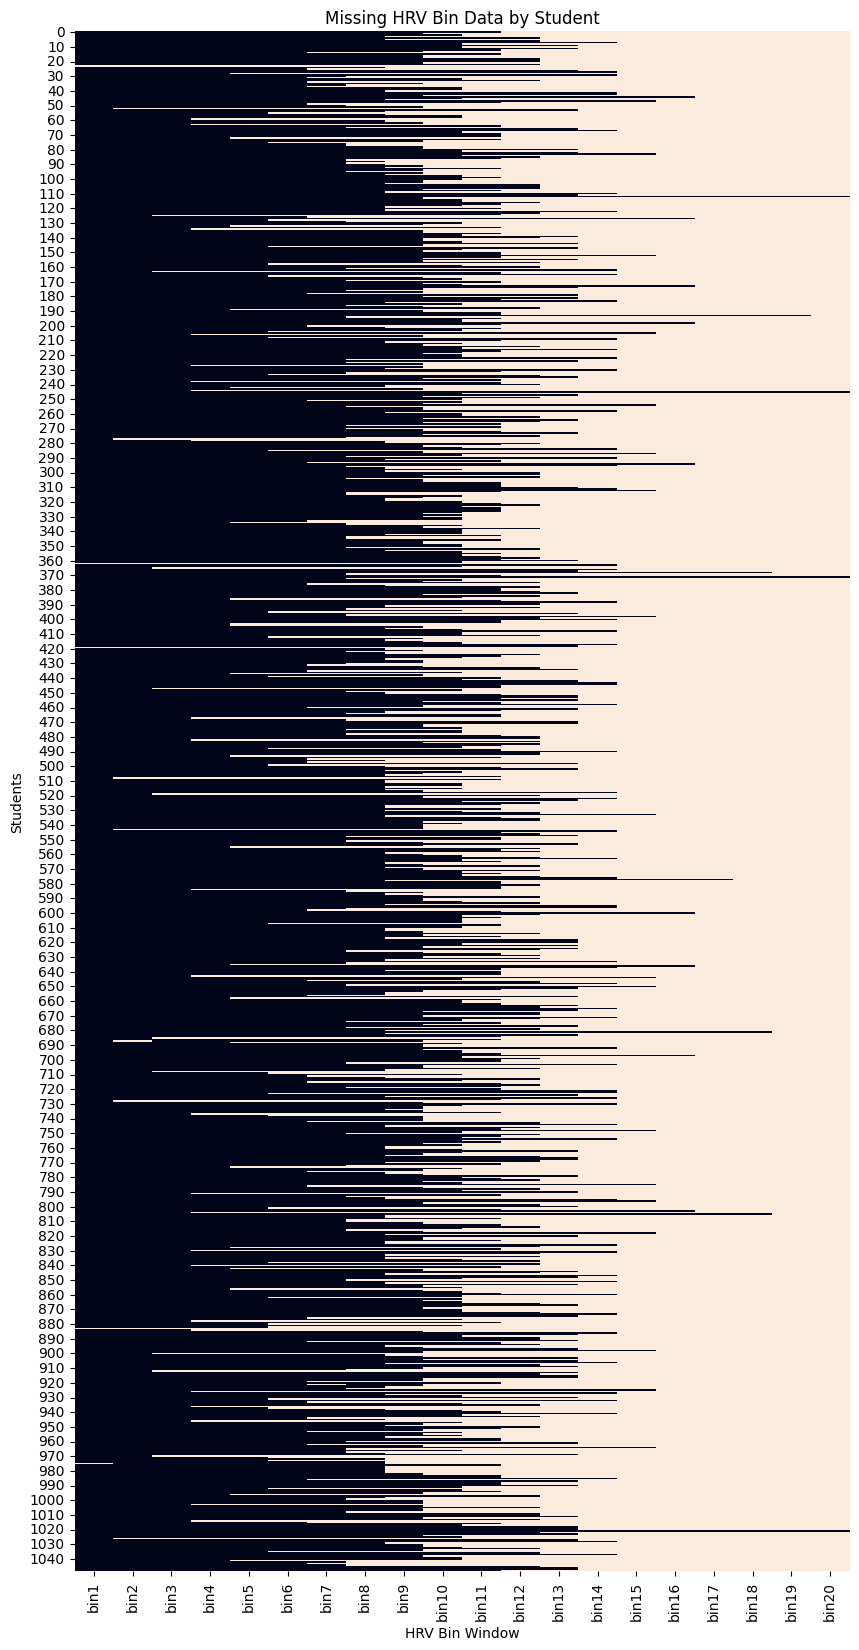

In [7]:
# student data across bins without session identifier

plt.figure(figsize=(10, 20))  # Width x Height in inches
sns.heatmap(df[bin_cols].isna(), cbar=False)

plt.xlabel("HRV Bin Window")
plt.ylabel("Students")
plt.title("Missing HRV Bin Data by Student")
plt.show()

# plot shows that student HRV bin data is not stable across sessions and duration


In [8]:

# Identify all BIN columns: bin1, bin2, ..., binN
bin_columns = [col for col in df.columns if col.lower().startswith("bin") and col[3:].isdigit()]

# Create presence indicators by counting non-null values across the selected columns
df["bin_presence"] = df[bin_columns].notnull().sum(axis=1)

df.head()



,StudentID,session,bin1,bin2,bin3,bin4,bin5,bin6,bin7,bin8,...,S8Emotion,S10Emotion,S11Emotion,S15Emotion,S18Emotion,S20Emotion,S24Emotion,S25Emotion,n_segments,bin_presence
0,2221,8,38052.193958,253.764910,614.802251,1232.755787,606.805480,353.630526,348.566931,402.816282,...,Yes,No,Yes,No,Yes,Yes,No,No,11,11
1,8115,18,1393.955999,865.590114,413.921771,495.959613,373.195983,1556.443728,4913.598631,1128.248557,...,Yes,No,Yes,No,Yes,Yes,No,No,9,9
2,5026,24,336.468908,388.047138,424.056372,574.569557,412.904901,378.198112,351.829760,295.189016,...,Yes,No,Yes,No,Yes,Yes,No,No,10,10
3,2205,11,233.230860,259.526925,231.537618,505.285336,331.303498,285.397727,287.870469,319.722232,...,Yes,No,Yes,No,Yes,Yes,No,No,8,8
4,8126,11,9946.804433,403.564178,611.011080,317.031456,306.382263,287.036936,254.065505,351.646434,...,Yes,No,Yes,No,Yes,Yes,No,No,12,12


In [9]:
# Create a presence matrix (1 = non-null, 0 = null)
bin_presence = df[bin_columns].notnull().astype(int)

# Add session column
bin_presence["session"] = df["session"]

print("Size =", bin_presence.shape)
bin_presence.head()


Size = (1049, 21)


,bin1,bin2,bin3,bin4,bin5,bin6,bin7,bin8,bin9,bin10,...,bin12,bin13,bin14,bin15,bin16,bin17,bin18,bin19,bin20,session
0,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,8
1,1,1,1,1,1,1,1,1,1,0,...,0,0,0,0,0,0,0,0,0,18
2,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,24
3,1,1,1,1,1,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,11
4,1,1,1,1,1,1,1,1,1,1,...,1,0,0,0,0,0,0,0,0,11


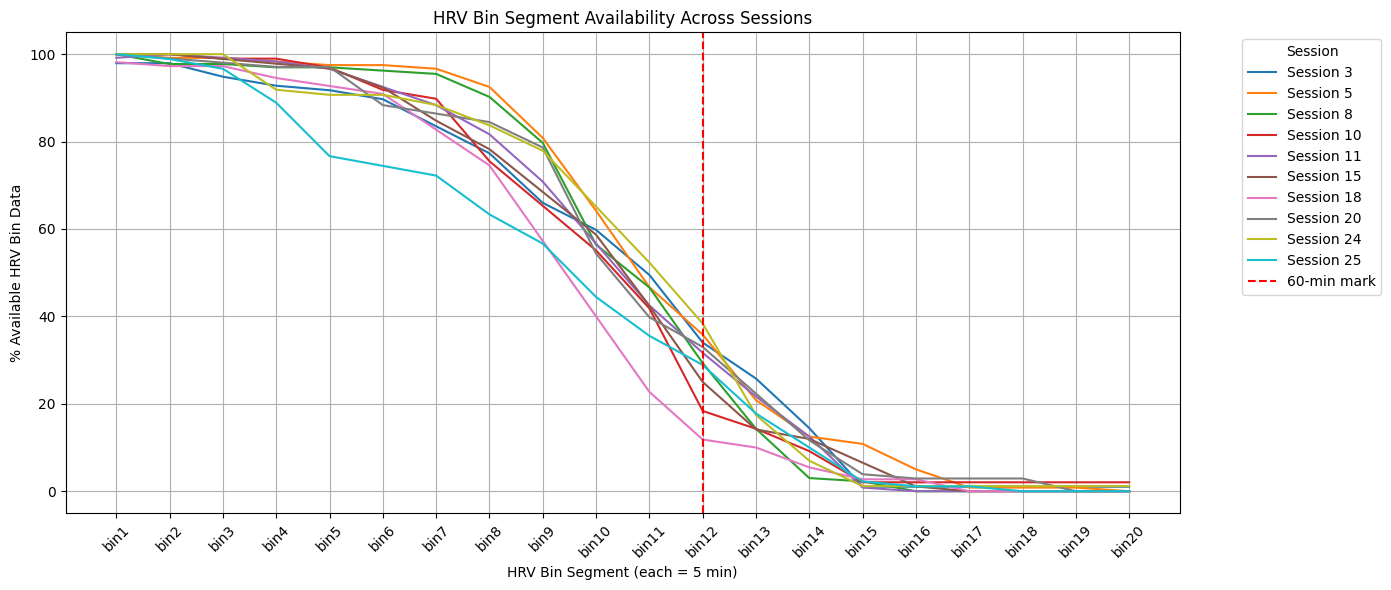

In [10]:
# Group by session and compute % of data available for each bin segment
session_bin_pct = bin_presence.groupby("session")[bin_columns].mean() * 100

# Plot as line plot to show longitudinal drop-offs
plt.figure(figsize=(14, 6))
for session in session_bin_pct.index:
    plt.plot(range(1, len(bin_columns) + 1), session_bin_pct.loc[session], label=f"Session {session}")

plt.xlabel("HRV Bin Segment (each = 5 min)")
plt.ylabel("% Available HRV Bin Data")
plt.axvline(x=12, color="red", linestyle="--", label="60-min mark")
plt.title("HRV Bin Segment Availability Across Sessions")
plt.xticks(range(1, len(bin_columns) + 1), bin_columns, rotation=45)
plt.legend(title="Session", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.tight_layout()
plt.show()


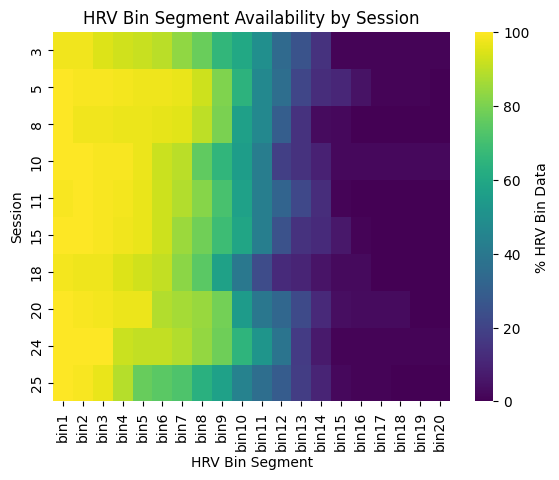

In [11]:
sns.heatmap(session_bin_pct, cmap="viridis", cbar_kws={"label": "% HRV Bin Data"})
plt.xlabel("HRV Bin Segment")
plt.ylabel("Session")
plt.title("HRV Bin Segment Availability by Session")
plt.show()


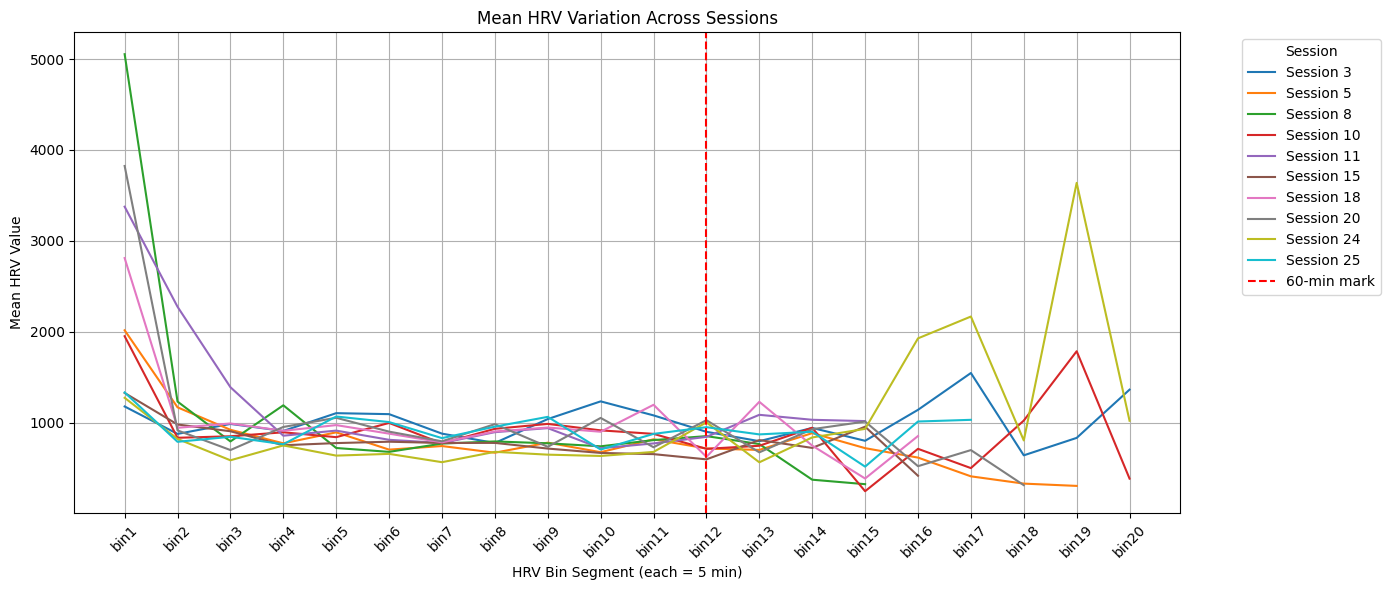

In [13]:
plt.figure(figsize=(14, 6))

# Compute mean HRV values per session × bin
session_bin_mean = df.groupby("session")[bin_columns].mean()

# Plot each session’s trajectory
for session in session_bin_mean.index:
    plt.plot(range(1, len(bin_columns)+1),
             session_bin_mean.loc[session],
             label=f"Session {session}")

plt.xlabel("HRV Bin Segment (each = 5 min)")
plt.ylabel("Mean HRV Value")
plt.title("Mean HRV Variation Across Sessions")
plt.axvline(x=12, color="red", linestyle="--", label="60-min mark")
plt.xticks(range(1, len(bin_columns)+1), bin_columns, rotation=45)
plt.legend(title="Session", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.tight_layout()
plt.show()


## Extreme HRV scores 

- I noticed that some students have very high HRV scores, maybe due to device malfunctioning.
- since the sample size is small, I followed more conservative approach to delete students with extreme HRV scores
- Basically, I took the log and if the HRV scores are still too high, I deleted those cases
- with this approach, I identified 11 cases

In [14]:
import numpy as np
import pandas as pd
from scipy.stats import zscore

# -------------------------------------------------
# 1. Aggregate across sessions → one row per student
# -------------------------------------------------
student_summary = (
    df.groupby("StudentID")[bin_columns]
      .mean()   # average across sessions
      .agg(["mean","min","max"], axis=1)  # then compute stats across bins
)

# -------------------------------------------------
# 2. Compute z-scores for each stat
# -------------------------------------------------
student_summary["z_mean"] = zscore(student_summary["mean"], nan_policy="omit")
student_summary["z_min"]  = zscore(student_summary["min"], nan_policy="omit")
student_summary["z_max"]  = zscore(student_summary["max"], nan_policy="omit")

# -------------------------------------------------
# 3. Flag students where ANY stat is extreme
# -------------------------------------------------
outlier_students = student_summary[
    (student_summary["z_mean"].abs() > 3) |
    (student_summary["z_min"].abs() > 3) |
    (student_summary["z_max"].abs() > 3)
]

print("Potential outlier students (aggregated across sessions):")
print(outlier_students)


Potential outlier students (aggregated across sessions):
                   mean          min           max    z_mean     z_min  \
StudentID                                                                
2104        1595.383578   986.412563   2825.274888  0.366588  3.033562   
2127        2622.573619  1109.049662  10300.746576  1.218088  3.694558   
2225        4029.284558   448.513853  37068.656042  2.384194  0.134366   
2226        5499.679186   585.796406  48949.793693  3.603093  0.874299   
4106        1570.349004   987.880812   2659.347365  0.345836  3.041475   
4126       12949.114872   236.635546  92543.902678  9.778375 -1.007628   
7023        1924.516728  1230.939814   2661.141340  0.639427  4.351528   

              z_max  
StudentID            
2104      -0.158237  
2127       0.635666  
2225       3.478447  
2226       4.740236  
4106      -0.175859  
4126       9.369978  
7023      -0.175668  


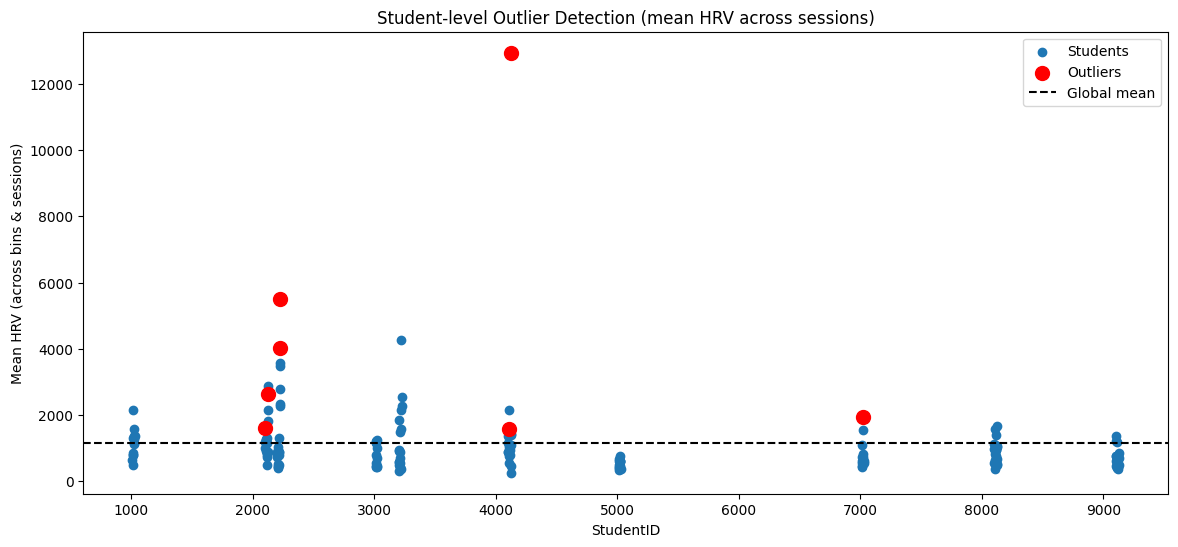

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
plt.scatter(student_summary.index, student_summary["mean"], label="Students")
plt.scatter(outlier_students.index, outlier_students["mean"], color="red", s=100, label="Outliers")
plt.axhline(student_summary["mean"].mean(), color="black", linestyle="--", label="Global mean")
plt.xlabel("StudentID")
plt.ylabel("Mean HRV (across bins & sessions)")
plt.title("Student-level Outlier Detection (mean HRV across sessions)")
plt.legend()
plt.show()


In [17]:
import numpy as np
import pandas as pd
from scipy.stats import zscore



# -----------------------------------------
# (a) Log-transform HRV bins (avoid log(0))
# -----------------------------------------
df_log = df.copy()
df_log[bin_columns] = np.log1p(df_log[bin_columns])  # log(1+x) to handle zeros safely

# -----------------------------------------
# (b) Re-check student-level outliers
# -----------------------------------------
# Step 1: aggregate across sessions → one row per student
student_summary = (
    df_log.groupby("StudentID")[bin_columns]
          .mean()  # average across sessions
          .agg(["mean","min","max"], axis=1)  # then mean/min/max across bins
)

# Step 2: compute z-scores
student_summary["z_mean"] = zscore(student_summary["mean"], nan_policy="omit")
student_summary["z_min"]  = zscore(student_summary["min"], nan_policy="omit")
student_summary["z_max"]  = zscore(student_summary["max"], nan_policy="omit")

# Step 3: flag outliers (Z>|3|)
outlier_students = student_summary[
    (student_summary["z_mean"].abs() > 3) |
    (student_summary["z_min"].abs() > 3) |
    (student_summary["z_max"].abs() > 3)
].index

print("Outlier StudentIDs after log-transform:")
print(outlier_students.tolist())

# -----------------------------------------
# (c) Add flag column back into df
# -----------------------------------------
df["is_outlier_student"] = df["StudentID"].isin(outlier_students).astype(int)

# Quick check
print(df["is_outlier_student"].value_counts())


Outlier StudentIDs after log-transform:
[2222, 2226, 4126, 9123, 9124]
is_outlier_student
0    1038
1      11
Name: count, dtype: int64


In [18]:
df[df["is_outlier_student"] == 1]


,StudentID,session,bin1,bin2,bin3,bin4,bin5,bin6,bin7,bin8,...,S10Emotion,S11Emotion,S15Emotion,S18Emotion,S20Emotion,S24Emotion,S25Emotion,n_segments,bin_presence,is_outlier_student
18,9123,8,456.050598,743.188059,994.895244,492.890906,220.297613,304.070165,1680.734998,719.574310,...,No,Yes,No,Yes,Yes,No,No,12,12,1
323,4126,18,92543.902678,10494.643935,22314.292833,1060.143155,236.635546,331.272110,1044.856194,405.236800,...,No,Yes,No,Yes,Yes,No,No,10,10,1
362,9123,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,No,Yes,No,Yes,Yes,No,No,0,0,1
368,9123,20,328.415389,303.312242,258.698876,286.794480,1594.697376,334.221008,325.695664,314.235407,...,No,Yes,No,Yes,Yes,No,No,18,18,1
689,2226,11,62147.186063,4424.019648,488.773308,1394.169611,2506.182808,787.281753,370.908232,845.835482,...,No,Yes,No,Yes,Yes,No,No,10,10,1
703,9123,11,399.460661,349.808070,1055.217443,396.264530,364.647064,465.251643,325.216029,788.589986,...,No,Yes,No,Yes,Yes,No,No,14,14,1
736,2226,18,17315.675514,2048.948671,2106.473677,1951.467052,3297.613533,1442.684028,2631.452125,962.613696,...,No,Yes,No,Yes,Yes,No,No,11,11,1
803,9124,5,73.279877,124.386153,663.509690,331.314492,200.457618,396.924068,259.985383,300.487111,...,No,Yes,No,Yes,Yes,No,No,16,16,1
898,9123,5,100.671435,343.648300,312.194731,308.062058,191.565946,253.367328,355.539475,291.748116,...,No,Yes,No,Yes,Yes,No,No,15,15,1
983,2226,8,67386.519502,454.962820,688.067777,243.323754,351.343435,303.411866,301.509431,278.476564,...,No,Yes,No,Yes,Yes,No,No,11,11,1


In [17]:
# Z-score check (>|3|) → marks outlier students.
df = df[df["is_outlier_student"] == 0]


print('Shape=', df.shape)

df.head()


Shape= (1038, 537)


,StudentID,session,bin1,bin2,bin3,bin4,bin5,bin6,bin7,bin8,...,S10Emotion,S11Emotion,S15Emotion,S18Emotion,S20Emotion,S24Emotion,S25Emotion,n_segments,bin_presence,is_outlier_student
0,2221,8,38052.193958,253.764910,614.802251,1232.755787,606.805480,353.630526,348.566931,402.816282,...,No,Yes,No,Yes,Yes,No,No,11,11,0
1,8115,18,1393.955999,865.590114,413.921771,495.959613,373.195983,1556.443728,4913.598631,1128.248557,...,No,Yes,No,Yes,Yes,No,No,9,9,0
2,5026,24,336.468908,388.047138,424.056372,574.569557,412.904901,378.198112,351.829760,295.189016,...,No,Yes,No,Yes,Yes,No,No,10,10,0
3,2205,11,233.230860,259.526925,231.537618,505.285336,331.303498,285.397727,287.870469,319.722232,...,No,Yes,No,Yes,Yes,No,No,8,8,0
4,8126,11,9946.804433,403.564178,611.011080,317.031456,306.382263,287.036936,254.065505,351.646434,...,No,Yes,No,Yes,Yes,No,No,12,12,0


#  Creating window size for analysis

- As shown above, data availability reduces tremendously after 60 seconds
-  since some clustering algorithms do not work with missing data, I want to explore reliable window size for the analysis
-  if we will use an algorithm that works with missing data, this part will be irrelevant
  

  **Another issue is variation in HRV scores:**
- our results show that at the beginning and at the end of the sessions, all HRV scores are high
- this might not be related to intervention delivery, instead adjustment of student into classroom and session settings
- some of them were still walking and even some of the session could contain short exercise
- so, I aimed to remove first and last parts of the session segments

**Results:**
- I ended up with selecting 2-9 as the primary window, referring most available data
- if we use missing value imputation, we will impute les data
- if useful, segments between 10-14 will be useful
- however, I deleted segments after 14
- more details below


In [19]:
# --- Goal --------------------------------------------------------------
# Create PRIMARY (landmark) and SECONDARY windows for HRV analysis that:
#   1) respect unequal session lengths,
#   2) avoid late-session informative missingness,
#
# Strategy (model-agnostic):
#   • Compute per-session, per-segment (% available) coverage.
#   • Choose the LARGEST cut point t* (in minutes) such that:
#       median_session_coverage(t*) ≥ COV_MEDIAN_MIN   AND
#       lower_quartile_session_coverage(t*) ≥ COV_Q1_MIN
#   • Use segments ≤ t* for the PRIMARY window; > t* for SECONDARY.
#
# Notes:
#   • Segments are 5-min bins: bin1=5, bin2=10, …
#   • If you also have sdN columns, they remain available for weights.


# --- METADATA / PARAMS ------------------------------------------------
SESSION_COL = "session"

# Coverage rules (tune as needed)
# I initially started with 80%, but to include more segments, I extenden lower and upper bonds
COV_MEDIAN_MIN = 65.0   # median coverage ≥ 80%
COV_Q1_MIN     = 50.0   # lower quartile coverage ≥ 60%

# Helper: map binN/sdN -> minutes (5 min per segment)
seg_to_minutes = lambda col: int(re.search(r"(\d+)$", col).group(1)) * 5

# Identify and sort BIN columns chronologically
bin_columns = sorted(
    [c for c in df.columns if c.lower().startswith("bin") and c[3:].isdigit()],
    key=seg_to_minutes
)

# let's trip the outlier segments and keep segment from 2 to 14
# this might be another concern, but my motivations here is to
# keep only more informative part of the data
# even after 40-45 minutes, data quality drops sharply
# at the same time, HRV changes rapidly
# to remove more likely outlier type segments of the data
# I decided to remove last parts of the HRV data, namely after segment 14
# Likewise, in the first 5 minutes, the higher HRV might be related to settling related behavior
# rather than intervention content or delivery 
bin_columns = bin_columns[1:14]  # hr2–hr14

print("Session column:", SESSION_COL)
print("Detected BIN columns (chronological):", bin_columns)

# --- COVERAGE BY SESSION x SEGMENT ------------------------------------
# Presence matrix: 1 = non-null, 0 = null
bin_presence = df[bin_columns].notnull().astype(int)

# Add session
bin_presence[SESSION_COL] = df[SESSION_COL]

# % available per session for each bin
session_bin_pct = bin_presence.groupby(SESSION_COL)[bin_columns].mean() * 100.0
# rows: sessions, cols: bin1..binN

# --- FIND LARGEST CUTPOINT t* -----------------------------------------
# Across sessions, compute median and Q1 for each bin column
median_by_bin = session_bin_pct.median(axis=0)            # pd.Series indexed by binN
q1_by_bin     = session_bin_pct.quantile(0.25, axis=0)    # same index

# Eligible bins = meet both thresholds
eligible = (median_by_bin >= COV_MEDIAN_MIN) & (q1_by_bin >= COV_Q1_MIN)
eligible_bins = list(median_by_bin.index[eligible])

if len(eligible_bins) > 0:
    # Choose the last (largest) eligible bin as t*
    t_star_col = sorted(eligible_bins, key=seg_to_minutes)[-1]
    t_star_minutes = seg_to_minutes(t_star_col)

    primary_bins   = [c for c in bin_columns if seg_to_minutes(c) <= t_star_minutes]
    secondary_bins = [c for c in bin_columns if seg_to_minutes(c) >  t_star_minutes]

    print(f"t* = {t_star_col} → {t_star_minutes} minutes")
    print("PRIMARY window bins:", primary_bins)
    print("SECONDARY window bins:", secondary_bins)
else:
    # Fallback if thresholds are too strict
    t_star_col = None
    t_star_minutes = 0
    primary_bins   = []
    secondary_bins = bin_columns.copy()
    print("No bin meets the coverage thresholds; all bins marked SECONDARY. Consider relaxing COV_MEDIAN_MIN / COV_Q1_MIN.")

# (Optional) Pack results in a dict for downstream use
landmark_spec = {
    "t_star_col": t_star_col,
    "t_star_minutes": t_star_minutes,
    "primary_bins": primary_bins,
    "secondary_bins": secondary_bins,
    "coverage_stats": {
        "median_by_bin": median_by_bin.to_dict(),
        "q1_by_bin": q1_by_bin.to_dict()
    },
    "thresholds": {"median_min": COV_MEDIAN_MIN, "q1_min": COV_Q1_MIN}
}


Session column: session
Detected BIN columns (chronological): ['bin2', 'bin3', 'bin4', 'bin5', 'bin6', 'bin7', 'bin8', 'bin9', 'bin10', 'bin11', 'bin12', 'bin13', 'bin14']
t* = bin9 → 45 minutes
PRIMARY window bins: ['bin2', 'bin3', 'bin4', 'bin5', 'bin6', 'bin7', 'bin8', 'bin9']
SECONDARY window bins: ['bin10', 'bin11', 'bin12', 'bin13', 'bin14']


In [20]:
# ----------------------------------------------------------------------
# COVERAGE: % available HRV bins per session × segment, plus cross-session summary
# ----------------------------------------------------------------------
def compute_segment_coverage(df, group_col, seg_cols):
    """
    Returns:
      coverage_by_session: DataFrame [session × segment] with % non-null
      coverage_summary   : DataFrame [segment] with median, q1, q3 across sessions
    """
    # % available within each session at each segment
    coverage_by_session = (
        df.groupby(group_col)[seg_cols]
          .apply(lambda g: g.notnull().sum() / len(g) * 100.0)
          .sort_index()
    )
    # Cross-session distribution for each segment
    coverage_summary = pd.DataFrame({
        "median": coverage_by_session.median(axis=0),
        "q1"    : coverage_by_session.quantile(0.25, axis=0),
        "q3"    : coverage_by_session.quantile(0.75, axis=0),
    })
    coverage_summary["minutes"] = [seg_to_minutes(c) for c in coverage_summary.index]
    return coverage_by_session, coverage_summary.sort_values("minutes")


# --- apply to BIN columns instead of HR columns ---
coverage_by_session, coverage_summary = compute_segment_coverage(
    df, SESSION_COL, bin_columns
)

# The values are percentages of non-null entries for that segment in that session.
# Example = Session 3, bin1 = 96.63 → in session 3, 96.6% of values in bin1 were non-missing.
# sensors/recordings tend to be reliable at the start of the session but coverage decreases toward the end.
#  Session differences: Some sessions have much higher sustained coverage (e.g., session 5 stays strong until bin10 before dropping),
#  while others lose coverage earlier (e.g., session 18 drops quickly after bin7).
print(coverage_by_session)


               bin2        bin3       bin4       bin5       bin6       bin7  \
session                                                                       
3         97.938144   94.845361  92.783505  91.752577  89.690722  83.505155   
5         99.166667   99.166667  98.333333  97.500000  97.500000  96.666667   
8         97.744361   97.744361  96.992481  96.992481  96.240602  95.488722   
10       100.000000   98.979592  98.979592  96.938776  91.836735  89.795918   
11       100.000000   99.166667  98.333333  96.666667  92.500000  88.333333   
15       100.000000   98.913043  97.826087  96.739130  92.391304  84.782609   
18        97.272727   97.272727  94.545455  92.727273  90.909091  82.727273   
20        99.029126   98.058252  97.087379  97.087379  88.349515  86.407767   
24       100.000000  100.000000  91.860465  90.697674  90.697674  88.372093   
25        98.888889   96.666667  88.888889  76.666667  74.444444  72.222222   

              bin8       bin9      bin10      bin11

In [20]:
print(coverage_summary)

# segments are aggregated across all sessions.
# The median % coverage across all sessions for that segment.
# Example: hr1 = 93.5 → in the first 5 minutes, the typical session has about 93.5% HR data available.

# Strong coverage early (0–30 min).
# Gradual decline mid-session (30–60 min).
# Collapse after ~65 minutes (hr13 onward).


          median         q1          q3  minutes
bin2   99.086075  98.320353  100.000000       10
bin3   98.521942  97.779035   99.109305       15
bin4   96.990950  93.419405   98.185335       20
bin5   96.674650  92.178919   96.934851       25
bin6   91.712760  89.942460   92.386699       30
bin7   87.205052  83.824518   89.439962       35
bin8   79.808401  75.962550   84.165527       40
bin9   69.408622  65.474437   78.300274       45
bin10  55.658409  54.216687   59.519274       50
bin11  42.382093  39.870948   45.668188       55
bin12  30.293351  25.972222   33.603699       60
bin13  17.609819  14.368132   20.762712       65
bin14  10.392157   7.528477   11.652542       70


In [21]:
# ----------------------------------------------------------------------
# CUT POINT SELECTION (coverage rule)
# ----------------------------------------------------------------------

# Recall Coverage rules
# COV_MEDIAN_MIN = 80.0   # median coverage ≥ 80%
# COV_Q1_MIN     = 60.0   # lower quartile coverage ≥ 60%

# Median ≥ X% → ensures the typical session has at least X% data coverage at that segment.
# Q1 ≥ Y% → ensures that even the worst 25% of sessions are not too poor in coverage.

# Alternative would be 75/50 → would likely push to bin9 (~45 min).
# Since HRV data may be sensitive to missingness, better to stay on conservative side.

# Find all segments that satisfy the coverage thresholds, then pick the LARGEST (latest) one.
eligible = coverage_summary[
    (coverage_summary["median"] >= COV_MEDIAN_MIN) &
    (coverage_summary["q1"]    >= COV_Q1_MIN)
]

if len(eligible) > 0:
    t_star_minutes = int(eligible["minutes"].max())
    t_star_segment = [c for c in bin_columns if seg_to_minutes(c) == t_star_minutes][0]
else:
    # Fallback (pre-specified) to 60 minutes if coverage rule finds none.
    t_star_minutes = 60
    # Find nearest existing segment ≤ 60 (e.g., bin12). If none, use the earliest available.
    candidates = [c for c in bin_columns if seg_to_minutes(c) <= t_star_minutes]
    t_star_segment = candidates[-1] if candidates else bin_columns[0]

print(f"[Window selection] PRIMARY landmark cut point t* = {t_star_minutes} min (segment: {t_star_segment}).")
print(coverage_summary.loc[[t_star_segment]])


[Window selection] PRIMARY landmark cut point t* = 45 min (segment: bin9).
         median         q1         q3  minutes
bin9  69.655797  65.474437  78.457327       45


In [22]:
# ----------------------------------------------------------------------
# DEFINE PRIMARY & SECONDARY WINDOWS (bins only, no SDs)
# ----------------------------------------------------------------------
primary_bin_cols   = [c for c in bin_columns if seg_to_minutes(c) <= t_star_minutes]
secondary_bin_cols = [c for c in bin_columns if seg_to_minutes(c) >  t_star_minutes]

analysis_windows = {
    "primary": {
        "minutes": (5, t_star_minutes),
        "bin_cols": primary_bin_cols
    },
    "secondary": {
        "minutes": (t_star_minutes + 5, seg_to_minutes(bin_columns[-1])),
        "bin_cols": secondary_bin_cols
    }
}

print("\n[Window columns]")
for name, cfg in analysis_windows.items():
    print(f"  • {name.upper():<9} {cfg['minutes'][0]:>2d}–{cfg['minutes'][1]:>3d} min | "
          f"{len(cfg['bin_cols'])} BIN segs")



[Window columns]
  • PRIMARY    5– 45 min | 8 BIN segs
  • SECONDARY 50– 70 min | 5 BIN segs


In [23]:
# ----------------------------------------------------------------------
#  OUTPUT OBJECTS for modeling stages
# ----------------------------------------------------------------------
# • coverage_by_session  : % availability per session × segment (for QC plots)
# • coverage_summary     : cross-session median/q1/q3 by segment (audit the cut point)
# • analysis_windows     : dict holding PRIMARY/SECONDARY minute ranges + bin columns
#
# Example usage in later steps:
#   X_primary   = df[analysis_windows["primary"]["bin_cols"]]
#   X_secondary = df[analysis_windows["secondary"]["bin_cols"]]
#
# For reproducibility in the paper, freeze the chosen t*:
PRIMARY_CUT_MINUTES = t_star_minutes  # << record this in your preregistration


# FIT DTM

**Next steps:**

  1. Fit DTM (or comparator FPCA/RR-LMM) on **hr2–hr9** to learn embeddings and cluster students.


In [24]:
# =================================================================================================
# DTM WORKFLOW — PRIMARY WINDOW (0–t*) with a plug-in “DTM-lite” embedding for now.
#
# Why this structure?
#   • This code uses a statistically principled surrogate faithful to
#     the DTM idea: learn a low-dimensional embedding of short, irregular time series and then
#     cluster the embeddings. The surrogate is:
#         (smoothing / imputation) + probabilistic PCA-style embedding + GMM clustering
#     with rigorous masking for missing segments and frozen preprocessing so we can project
#     partial sessions later (early-warning).
#
# Inputs expected from previous steps:
#   • df                   : table with one row per student×session; columns bin1..binN
#   • analysis_windows     : dict with 'primary'/'secondary' -> {'bin_cols', 'minutes'}
#   • PRIMARY_CUT_MINUTES  : chosen landmark cut point in minutes (e.g., 40)
#
# Outputs created here:
#   • DTMModel object with .fit(), .transform(), .fit_transform(), .project_partial()
#   • df_embed: DataFrame with embedding coordinates (z1,z2,...) and cluster labels
#   • gmm_model: fitted GaussianMixture for downstream responsibilities / early warning
#
# Reproducibility: set RNG_SEED and keep it fixed for your preregistration.
# =================================================================================================

RNG_SEED = 17

# Grab the PRIMARY window columns -----------------------------------------------------------
primary_bin_cols = analysis_windows["primary"]["bin_cols"]
assert len(primary_bin_cols) > 0, "PRIMARY window not defined. Run the window-selection block first."
T = len(primary_bin_cols)

# Helper: segment name -> minutes
def seg_to_minutes(colname: str) -> int:
    return int(re.search(r"(\d+)$", colname).group(1)) * 5

# Time grid (in minutes) for reference / later visualization
t_minutes = np.array([seg_to_minutes(c) for c in primary_bin_cols])

# Build the modeling matrix with explicit masking -------------------------------------------
# X_raw: shape [N × T]
# Rows = sessions (student × session) → each observation.
# Columns = HRV bin segments within the primary window (bin1–binK).


USE_LOG_HRV = True # False
X_raw = df[primary_bin_cols].copy()
if USE_LOG_HRV:
    X_raw = np.log1p(X_raw)

print(X_raw.head())


       bin2      bin3      bin4      bin5      bin6      bin7      bin8  \
0  5.540341  6.422926  7.117818  6.409855  5.871076  5.856695  6.000960   
1  6.764566  6.028090  6.208509  5.924780  7.350801  8.499965  7.029308   
2  5.963701  6.052222  6.355360  6.025636  5.938059  5.865986  5.690998   
3  5.562706  5.449052  6.227100  5.806049  5.657381  5.665978  5.770575   
4  6.002810  6.416750  5.762150  5.728092  5.663089  5.541520  5.865466   

       bin9  
0  6.560293  
1  6.292071  
2  5.904280  
3       NaN  
4  5.781829  


In [25]:
# a boolean mask of the same shape, where True = observed (not missing), False = missing (NaN).
M = ~X_raw.isna().values
M


array([[ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       ...,
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True]])

In [26]:
# the number of observations (rows in df_physio).
N = X_raw.shape[0]
print('Length=', N)


Length= 1049


In [ ]:
# let's create also another matrix with primary and secondary windows
# when needed, we can use the full matrix


# secondary window
secondary_bin_cols = analysis_windows["secondary"]["bin_cols"]

assert len(secondary_bin_cols) > 0, "SECONDARY window not defined."

# Combine in time order (PRIMARY first, then SECONDARY)
full_bin_cols = primary_bin_cols + secondary_bin_cols


# Convert bin names → minutes (same helper logic) 
t_full_minutes = np.array([seg_to_minutes(c) for c in full_bin_cols])


#  Build the FULL modeling matrix 
USE_LOG_HRV = True  # same flag you used above

X_full = df[full_bin_cols].copy()

if USE_LOG_HRV:
    X_full = np.log1p(X_full)


# --- 4. Inspect -------------------------------------------------------------------------------
print("FULL MATRIX (PRIMARY + SECONDARY):")
print(X_full.head())
print("Shape:", X_full.shape)
print("Total bins:", len(full_bin_cols))


FULL MATRIX (PRIMARY + SECONDARY):
       bin2      bin3      bin4      bin5      bin6      bin7      bin8  \
0  5.540341  6.422926  7.117818  6.409855  5.871076  5.856695  6.000960   
1  6.764566  6.028090  6.208509  5.924780  7.350801  8.499965  7.029308   
2  5.963701  6.052222  6.355360  6.025636  5.938059  5.865986  5.690998   
3  5.562706  5.449052  6.227100  5.806049  5.657381  5.665978  5.770575   
4  6.002810  6.416750  5.762150  5.728092  5.663089  5.541520  5.865466   

       bin9     bin10     bin11     bin12  bin13  bin14  
0  6.560293  7.399381  6.157460       NaN    NaN    NaN  
1  6.292071       NaN       NaN       NaN    NaN    NaN  
2  5.904280  6.060663       NaN       NaN    NaN    NaN  
3       NaN       NaN       NaN       NaN    NaN    NaN  
4  5.781829  6.177396  5.744707  5.829837    NaN    NaN  
Shape: (1049, 13)
Total bins: 13


## Version I (ChatGPT produced code and explanations)


### What matches the paper’s intent

* **Low-dimensional embedding of trajectories** for visualization/clustering and outcome analysis ↔ the paper’s central objective.
* **Handling missingness** before embedding (you use explicit masks + imputation; the paper models irregular sampling natively via subject-specific design matrices $B_i$).&#x20;
* **Projecting partial trajectories** (your `project_partial`) ↔ the paper’s ability to infer/posterior-predict from partial histories.&#x20;

### Where it diverges from the DTM methodology (the important bits)

1. **Model class**

* Yours: deterministic pipeline = IterativeImputer (BayesianRidge) → per-timepoint standardization → **PCA**.
* Paper: **generative model** derived from reduced-rank LMM; marginalize basis weights to obtain a **GP over trajectories/coefficients** with a **kernel in the latent space $x_i$**; learn with **stochastic variational inference** and **inducing points**; keep **posterior uncertainty** over $x_i$ and GP parameters.&#x20;

2. **Basis / time handling**

* Yours: fixed, equally-spaced bins (hr1…hr8) after coverage gating; impute onto that grid.
* Paper: each subject has a **design matrix $B_i$** (e.g., B-splines) evaluated at that subject’s **actual observation times**, so **irregular sampling is native** (no pre-imputation grid needed).&#x20;

3. **Uncertainty & inference**

* Yours: single point embedding (no posterior over $x_i$); clustering uses a downstream GMM on PCA scores.
* Paper: maintains **variational posteriors** over $x_i$ and inducing variables; supports **posterior predictive** for new/partial trajectories and principled uncertainty in downstream tests.&#x20;

4. **Learning objective**

* Yours: unsupervised reconstruction variance (PCA) after imputation.
* Paper: maximizes a **variational ELBO** for the DTM likelihood with kernel hyperparameters, inducing inputs, etc. (scales via SVI).&#x20;

### Why this matters

* **Bias from imputation:** deterministic imputation + PCA can distort shapes, especially under nonrandom missingness.
* **Irregular timing:** binning loses information that $B_i$ preserves.
* **No uncertainty:** you can’t propagate embedding uncertainty into clustering or outcome association tests, which the paper explicitly does.&#x20;

In [28]:
# --- Imports you need somewhere once ------------------------------------------
from sklearn.experimental import enable_iterative_imputer  # noqa: F401  <-- REQUIRED
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np
import pandas as pd

# --- DTM-lite model ------------------------------------------------------------
class DTMModel:
    """
    DTM-lite embedding:
      • IterativeImputer (BayesianRidge) to complete missing segments.
      • Column-standardize (per time bin) to emphasize shape over level.
      • PCA to obtain a low-dim latent space (q=2–3 typical).
      • Frozen preprocessing enables .project_partial().

    Notes:
      - Columns that are ALL NaN across rows are dropped at fit and remembered.
      - At transform/project_partial, those columns are ignored consistently.
    """
    def __init__(self, q=3, impute_max_iter=25, random_state=17):
        self.q = q
        self.imputer = IterativeImputer(
            max_iter=impute_max_iter, random_state=random_state, sample_posterior=False
        )
        self.scaler = StandardScaler(with_mean=True, with_std=True)
        self.pca = PCA(n_components=q, random_state=random_state)
        self._cols_keep = None       # columns actually used (non all-NaN at fit)
        self.fitted_ = False

    # ---- internals -------------------------------------------------------------
    def _select_fit_columns(self, X: pd.DataFrame):
        # drop columns that are entirely NaN across rows (IterativeImputer cannot learn them)
        all_nan = X.columns[X.isna().all(axis=0)]
        cols_keep = [c for c in X.columns if c not in set(all_nan)]
        if len(cols_keep) == 0:
            raise ValueError("All features are NaN; cannot fit DTMModel.")
        return cols_keep

    def _align_and_subset(self, X: pd.DataFrame):
        # ensure the input has at least the training columns in the same order
        missing = [c for c in self._cols_keep if c not in X.columns]
        if missing:
            raise ValueError(f"Input is missing columns seen at fit: {missing}")
        Xs = X[self._cols_keep].copy()
        return Xs

    # ---- API -------------------------------------------------------------------
    def fit(self, X: pd.DataFrame):
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X)
        self._cols_keep = self._select_fit_columns(X)
        X_fit = X[self._cols_keep].copy()

        # 1) learn imputer, complete the matrix
        X_imp = self.imputer.fit_transform(X_fit)

        # 2) per-timepoint z-scoring
        X_z = self.scaler.fit_transform(X_imp)

        # 3) PCA on standardized data
        self.pca.fit(X_z)

        self.fitted_ = True
        return self

    def transform(self, X: pd.DataFrame):
        assert self.fitted_, "Call .fit() first."
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X)
        Xs = self._align_and_subset(X)

        # impute with frozen imputer
        X_imp = self.imputer.transform(Xs)

        # standardize with frozen scaler
        X_z = self.scaler.transform(X_imp)

        # project to latent space
        Z = self.pca.transform(X_z)
        return Z

    def fit_transform(self, X: pd.DataFrame):
        self.fit(X)
        return self.transform(X)

    def project_partial(self, X_partial: pd.DataFrame):
        """
        Project partial trajectories (some segments missing). Uses the same
        imputer + scaler + PCA learned in fit().
        """
        return self.transform(X_partial)


### Version II

- What it does (closer to the paper’s spirit):

- Projects each row’s time series onto a smooth basis (default: cubic polynomial basis; optional: B-splines if patsy is installed).

- Estimates ridge-regularized coefficients per row with masking (no pre-impute to a grid).

- Standardizes coefficients across subjects.

- Uses Factor Analysis (probabilistic) for a low-dim embedding (instead of PCA), giving you a likelihood-based latent model.

In [29]:
import numpy as np
import pandas as pd
from sklearn.decomposition import FactorAnalysis
from sklearn.preprocessing import StandardScaler

# Optional: B-splines via patsy (if available). Falls back to cubic polynomials otherwise.
try:
    from patsy import dmatrix as _dmatrix
    _HAS_PATSY = True
except Exception:
    _HAS_PATSY = False


class DTMModel_FPCA:
    """
    DTM-like (functional baseline):
      1) Build a smooth basis B(t) over your primary window times.
      2) For each row i, solve masked ridge:  beta_i = argmin ||W_i (y_i - B beta)||^2 + alpha||beta||^2
         where W_i masks missing segments.
      3) Standardize coefficients across rows; embed with FactorAnalysis (probabilistic).
      4) project_partial() recomputes coefficients from the available segments using the *same* basis & ridge.
    """
    def __init__(self, q=3, basis="auto", n_basis=5, ridge_alpha=1.0, random_state=17):
        """
        q          : latent dim
        basis     : 'auto' -> use 'bspline' if patsy present else 'poly'
                     'bspline' or 'poly' explicitly set
        n_basis   : #basis functions (df for splines; degree+1 for poly is fixed to 4 for cubic)
        ridge_alpha: ridge penalty for coefficient stability
        """
        self.q = q
        self.ridge_alpha = ridge_alpha
        self.random_state = random_state
        self.n_basis = n_basis
        self.basis = ("bspline" if (_HAS_PATSY and basis == "auto") else
                      ("poly" if basis == "auto" else basis))
        # learned/frozen params
        self._B = None           # [T × K] basis at training grid
        self._BtWB = None        # cached normal matrix per unique mask size (built on the fly)
        self._scaler = StandardScaler(with_mean=True, with_std=True)
        self._fa = FactorAnalysis(n_components=q, random_state=random_state)
        self._t_grid = None
        self.fitted_ = False

    # ---- helpers -----------------------------------------------------------------
    @staticmethod
    def _safe_minmax(x):
        x = np.asarray(x, float)
        lo, hi = np.nanmin(x), np.nanmax(x)
        if hi <= lo:  # degenerate
            return np.zeros_like(x)
        return (x - lo) / (hi - lo)

    def _build_basis(self, t_minutes):
        """
        Return B [T×K] evaluated at provided t grid.
        If 'poly': cubic polynomial [1, t, t^2, t^3] with t scaled to [0,1].
        If 'bspline': cubic B-splines with n_basis df (no intercept).
        """
        t_scaled = self._safe_minmax(t_minutes).reshape(-1, 1)  # [T×1] in [0,1]
        T = t_scaled.shape[0]
        if self.basis == "poly":
            # cubic polynomial basis (K=4), smooth surrogate if you can’t rely on patsy/scipy
            B = np.concatenate([np.ones((T, 1)),
                                t_scaled,
                                t_scaled**2,
                                t_scaled**3], axis=1)  # [T×4]
            return B
        else:
            # bspline via patsy
            # K = n_basis, degree=3, exclude intercept
            # NOTE: t_scaled.flatten() goes to 'x' in the dmatrix
            B = _dmatrix("bs(x, df=%d, degree=3, include_intercept=False)" % self.n_basis,
                         {"x": t_scaled.flatten()}, return_type="dataframe").to_numpy()
            return np.asarray(B, float)

    def _masked_ridge_solve(self, y, B, alpha):
        """
        Solve (B^T W B + alpha I) beta = B^T W y,
        where W is diagonal with 1 for observed entries, 0 for NaNs.
        """
        y = np.asarray(y, float)
        mask = ~np.isnan(y)
        if mask.sum() == 0:
            # no data → return zeros
            return np.zeros(B.shape[1], dtype=float)
        Bo = B[mask, :]                    # observed rows only
        yo = y[mask]
        # normal equations
        BtB = Bo.T @ Bo
        BtY = Bo.T @ yo
        K = BtB.shape[0]
        beta = np.linalg.solve(BtB + alpha * np.eye(K), BtY)
        return beta

    # ---- API ---------------------------------------------------------------------
    def fit(self, X: pd.DataFrame, t_minutes=None):
        """
        X: [N×T] DataFrame with NaNs allowed.
        t_minutes: optional array-like of length T; if None, infer from columns like 'hr8' → 40.
        """
        if t_minutes is None:
            # infer minutes from column names ending with 1..18, each bin = 5 min
            import re
            def seg_to_minutes(col):
                m = re.search(r"(\d+)$", col)
                return int(m.group(1)) * 5 if m else None
            t_minutes = np.array([seg_to_minutes(c) for c in X.columns], dtype=float)

        self._t_grid = np.asarray(t_minutes, float)
        self._B = self._build_basis(self._t_grid)   # [T×K]
        K = self._B.shape[1]

        # coefficient matrix [N×K]
        coefs = np.zeros((X.shape[0], K), dtype=float)
        for i, (_, row) in enumerate(X.iterrows()):
            coefs[i, :] = self._masked_ridge_solve(row.values, self._B, self.ridge_alpha)

        # standardize across subjects
        coefs_z = self._scaler.fit_transform(coefs)

        # probabilistic embedding
        self._fa.fit(coefs_z)
        self.fitted_ = True
        return self

    def transform(self, X: pd.DataFrame):
        assert self.fitted_, "Call .fit() first."
        # compute coefficients with the *same* basis, same ridge
        coefs = np.vstack([self._masked_ridge_solve(row.values, self._B, self.ridge_alpha)
                           for _, row in X.iterrows()])
        coefs_z = self._scaler.transform(coefs)
        Z = self._fa.transform(coefs_z)  # [N×q]
        return Z

    def fit_transform(self, X: pd.DataFrame):
        self.fit(X)
        return self.transform(X)

    def project_partial(self, X_partial: pd.DataFrame):
        # identical to transform(): masked ridge + scaler + FA
        return self.transform(X_partial)


## Version III

**What it does (another principled surrogate):**

- Implements EM-PCA for data with NaNs:

- Initialize missing entries with column means.

- Alternate: (E) fill NaNs with current low-rank reconstruction; (M) refit PCA on the completed matrix.

- No separate imputer; mask is honored during reconstruction.

- Standardizes per time bin (shape emphasis), like your current model.

- Returns scores as the embedding; project_partial() runs EM steps only for the rows you pass using the learned loadings (fast “fold-in”).


We turn each student’s minute-by-minute heart-rate curve into three numbers that capture its overall shape.

Because some minutes are missing, we use an iterative fill-and-refit approach: we fit a compact “shape model” to the parts we see, use it to predict the missing minutes, refit, and repeat until things stop changing.

Once that “shape model” is learned, we can take a partially observed new session (say the first 10–30 minutes), and place it onto the same map using only the minutes we’ve seen. 

These three numbers (the embedding) are then used to cluster sessions and to predict early on whether a student is likely to be non-responsive to the intervention.

In [30]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

class DTMModel_EMPCA:
    """
    EM-PCA with missing data:
      - Keeps masking; no external imputer.
      - Column standardization (shape over level).
      - Low-rank reconstruction iterates until convergence; embeddings are PCA scores.
      - project_partial() fold-in with fixed loadings.
    """
    def __init__(self, q=3, max_em_iters=50, tol=1e-5, random_state=17):
        self.q = q
        self.max_em_iters = max_em_iters
        self.tol = tol
        self.random_state = random_state
        self._scaler = StandardScaler(with_mean=True, with_std=True)
        self._pca = PCA(n_components=q, random_state=random_state)
        self._loadings = None  # [T×q]
        self._col_means = None
        self.fitted_ = False

    def _complete_with_means(self, X):
        Xc = X.copy()
        # fill NaNs with column means
        for j in range(Xc.shape[1]):
            col = Xc[:, j]
            m = np.nanmean(col)
            col[np.isnan(col)] = m
            Xc[:, j] = col
        return Xc

    def fit(self, X: pd.DataFrame):
        Xv = X.values.astype(float)
        mask = ~np.isnan(Xv)

        # init: fill with column means
        X_complete = self._complete_with_means(Xv)
        # standardize per time bin
        Xz = self._scaler.fit_transform(X_complete)

        prev_obj = None
        for it in range(self.max_em_iters):
            # M-step: fit PCA loadings/scores on completed, standardized data
            self._pca.fit(Xz)
            L = self._pca.components_.T    # [T×q]
            S = self._pca.transform(Xz)    # [N×q]
            Xhat = S @ L.T                 # reconstruction in z-space

            # E-step: put back observed values; update missing with reconstruction
            Xz_new = Xz.copy()
            # For observed entries, enforce original standardized values
            Xz_new[mask] = Xz[mask]
            # For missing entries, replace with reconstruction
            Xz_new[~mask] = Xhat[~mask]

            # Check convergence via change in reconstruction on missing entries
            diff = np.linalg.norm((Xz_new - Xz)[~mask]) / (np.sqrt((~mask).sum()) + 1e-9)
            Xz = Xz_new
            if diff < self.tol:
                break

        # Final fit on the converged completed data
        self._pca.fit(Xz)
        self._loadings = self._pca.components_.T  # [T×q]
        self.fitted_ = True
        return self

    def transform(self, X: pd.DataFrame):
        assert self.fitted_, "Call .fit() first."
        Xv = X.values.astype(float)
        mask = ~np.isnan(Xv)

        # Standardize with training scaler, keeping NaNs
        X_center = (Xv - self._scaler.mean_) / (self._scaler.scale_ + 1e-9)

        # One-step fold-in EM for rows: initialize missing with 0 in z-space (mean), then solve for scores
        # Given loadings L, scores s minimize || P_mask( Xz - s L^T ) ||^2 → closed-form per row
        L = self._loadings  # [T×q]
        Z = np.zeros((Xv.shape[0], self.q), dtype=float)

        for i in range(Xv.shape[0]):
            mi = mask[i, :]
            if mi.sum() == 0:
                Z[i, :] = 0.0
                continue
            Li = L[mi, :]                  # [Ti×q]
            xi = X_center[i, mi]           # [Ti]
            # normal equations: (Li^T Li) s = Li^T xi
            A = Li.T @ Li + 1e-6 * np.eye(self.q)
            b = Li.T @ xi
            Z[i, :] = np.linalg.solve(A, b)

        return Z

    def fit_transform(self, X: pd.DataFrame):
        self.fit(X)
        return self.transform(X)

    def project_partial(self, X_partial: pd.DataFrame):
        # same as transform(): fold-in using fixed loadings and training scaler
        return self.transform(X_partial)


### Run the Models

In [31]:
#  Helper function to Choose #clusters via BIC (and report silhouette as a descriptive check) -------------------
def choose_gmm_k(Z, k_min=2, k_max=6, random_state=RNG_SEED):
    best = None
    rows = []
    for k in range(k_min, k_max + 1):
        gmm = GaussianMixture(n_components=k, covariance_type="full",
                              reg_covar=1e-6, random_state=random_state, n_init=5)
        gmm.fit(Z)
        bic = gmm.bic(Z)
        try:
            sil = silhouette_score(Z, gmm.predict(Z))
        except Exception:
            sil = np.nan
        rows.append({"k": k, "bic": bic, "silhouette": sil})
        if best is None or bic < best["bic"]:
            best = {"k": k, "model": gmm, "bic": bic, "silhouette": sil}
    return best, pd.DataFrame(rows).sort_values("k")



In [32]:
def package_results(Z, resp, labels, k_star, df_index, model_tag, q_latent, primary_minutes):
    emb_cols = [f"emb_{model_tag}{i+1}" for i in range(q_latent)]
    df_embed = pd.DataFrame(Z, columns=emb_cols, index=df_index)
    for j in range(k_star):
        df_embed[f"p_cluster_{model_tag}{j+1}"] = resp[:, j]
    df_embed[f"cluster_{model_tag}"] = labels + 1          # 1..K
    df_embed[f"cluster_k_{model_tag}"] = k_star
    df_embed[f"primary_minutes_{model_tag}"] = primary_minutes
    return df_embed


In [33]:
def run_model_variant(model, X_raw, df, model_tag, q_latent,
                      k_min=2, k_max=6, random_state=17, save=True):
    """Fits model → picks K via BIC → prints QC → packages & (optionally) saves."""
    import numpy as np

    # --- fit + embed
    Z = model.fit_transform(X_raw)

    # --- choose K
    best, grid = choose_gmm_k(Z, k_min=k_min, k_max=k_max, random_state=random_state)
    gmm = best["model"]
    k_star = best["k"]
    sil = best.get("silhouette", np.nan)

    # --- responsibilities + labels
    resp = gmm.predict_proba(Z)
    labels = gmm.predict(Z)

    # --- package
    df_embed = package_results(
        Z=Z, resp=resp, labels=labels, k_star=k_star,
        df_index=df.index, model_tag=model_tag,
        q_latent=q_latent, primary_minutes=PRIMARY_CUT_MINUTES
    )

    # --- merge (unique column names prevent collisions)
    df_out = pd.concat([df, df_embed], axis=1)

    # --- prints (mirrors your previous style)
    T = len(primary_bin_cols)
    print(f"[{model_tag}] Primary window: 0–{PRIMARY_CUT_MINUTES} min across {T} segments "
          f"({primary_bin_cols[0]}..{primary_bin_cols[-1]}).")
    if np.isnan(sil):
        sil_msg = "NA"
    else:
        sil_msg = f"{sil:.3f}"
    print(f"[{model_tag}] Latent dim q = {q_latent}.  Selected clusters K = {k_star}.  Silhouette(K*) = {sil_msg}")
    print(f"[{model_tag}] GMM model-selection grid (lower BIC is better):")
    print(grid)

    # cluster sizes (quick sanity check)
    counts = pd.Series(labels + 1).value_counts().sort_index()
    print(f"[{model_tag}] Cluster counts (1..K):")
    print(counts.to_string())

    # --- save (optional)
    if save:
        df_embed.to_csv(f"embed_{model_tag}.csv", index=True)
        grid.to_csv(f"gmm_grid_{model_tag}.csv", index=False)
        print(f"[{model_tag}] Saved: embed_{model_tag}.csv, gmm_grid_{model_tag}.csv")

    # Return everything you might want later
    return {
        "Z": Z, "gmm": gmm, "grid": grid, "k_star": k_star,
        "resp": resp, "labels": labels, "df_embed": df_embed
    }, df_out


In [34]:
# DTM-lite
q_latent = 3
dtm = DTMModel(q=q_latent, impute_max_iter=25, random_state=RNG_SEED)
dtm_artifacts, df = run_model_variant(
    model=dtm,
    X_raw=X_raw,
    df=df,
    model_tag="DTM",
    q_latent=q_latent,
    k_min=2, k_max=6,
    random_state=RNG_SEED,
    save=True
)

[DTM] Primary window: 0–45 min across 8 segments (bin2..bin9).
[DTM] Latent dim q = 3.  Selected clusters K = 3.  Silhouette(K*) = 0.144
[DTM] GMM model-selection grid (lower BIC is better):
   k          bic  silhouette
0  2  9321.589561    0.300438
1  3  9285.480703    0.143588
2  4  9346.912826    0.139241
3  5  9388.102582    0.134975
4  6  9446.581510    0.138438
[DTM] Cluster counts (1..K):
1    336
2    621
3     92
[DTM] Saved: embed_DTM.csv, gmm_grid_DTM.csv


In [ ]:
# EMPCA
q_latent = 3
dtm_EMPCA = DTMModel_EMPCA(q=q_latent, max_em_iters=50, tol=1e-5, random_state=RNG_SEED)
empca_artifacts, df_physio = run_model_variant(
    model=dtm_EMPCA,
    X_raw=X_full, # here we used full matrix
    df=df,
    model_tag="EMPCA",
    q_latent=q_latent,
    k_min=2, k_max=6,
    random_state=RNG_SEED,
    save=True
)




[EMPCA] Primary window: 0–45 min across 8 segments (bin2..bin9).
[EMPCA] Latent dim q = 3.  Selected clusters K = 5.  Silhouette(K*) = 0.159
[EMPCA] GMM model-selection grid (lower BIC is better):
   k           bic  silhouette
0  2  17283.042264    0.745562
1  3  16962.990428    0.169653
2  4  16930.940061    0.159346
3  5  16921.340669    0.159431
4  6  16964.899765    0.168458
[EMPCA] Cluster counts (1..K):
1    427
2      1
3      2
4     55
5    564
[EMPCA] Saved: embed_EMPCA.csv, gmm_grid_EMPCA.csv


In [36]:
# FPCA (optional second run)
dtm_FPCA = DTMModel_FPCA(q=q_latent, basis="auto", n_basis=6, ridge_alpha=1.0, random_state=RNG_SEED)
fpca_artifacts, df = run_model_variant(
    model=dtm_FPCA,
    X_raw=X_raw,
    df=df,
    model_tag="FPCA",
    q_latent=q_latent,
    k_min=2, k_max=6,
    random_state=RNG_SEED,
    save=True
)

[FPCA] Primary window: 0–45 min across 8 segments (bin2..bin9).
[FPCA] Latent dim q = 3.  Selected clusters K = 4.  Silhouette(K*) = 0.140
[FPCA] GMM model-selection grid (lower BIC is better):
   k          bic  silhouette
0  2  7613.882917    0.600853
1  3  7245.821555    0.125893
2  4  7068.989546    0.139993
3  5  7078.332416    0.231937
4  6  7129.144647    0.213042
[FPCA] Cluster counts (1..K):
1     71
2     20
3    576
4    382
[FPCA] Saved: embed_FPCA.csv, gmm_grid_FPCA.csv


## Summary

**Quick tips on choosing between A vs B**

- A (FPCA) is great if you want explicit smoothness in time (basis coefficients), easy early-warning projection, and a probabilistic embedding (FA).

- B (EM-PCA) is great if you want mask-aware low-rank structure without a separate imputer, minimal moving parts, and very fast fold-in for partial rows.

Both keep your downstream cluster selection (BIC/silhouette), responsibilities, and the packaging of outputs exactly the same. If you want, I can add an option in each class to accept your w_primary row-weights for sensitivity runs (applied in the coefficient solve for A, and as weighted least squares in fold-in for B).

In [37]:
import numpy as np
import pandas as pd
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy.special import xlogy

def fit_gmm_grid(Z, k_list=range(2,7), random_state=17, n_init=5):
    rows, models = [], {}
    for k in k_list:
        gmm = GaussianMixture(n_components=k, covariance_type="full",
                              reg_covar=1e-6, random_state=random_state, n_init=n_init)
        gmm.fit(Z)
        bic = gmm.bic(Z)
        try:
            sil = silhouette_score(Z, gmm.predict(Z))
        except Exception:
            sil = np.nan
        models[k] = gmm
        rows.append({"k": k, "bic": bic, "silhouette": sil})
    return pd.DataFrame(rows), models

def icl_score(gmm, Z):
    # ICL ≈ BIC + entropy penalty (negative conditional log-likelihood of cluster labels)
    # Lower is better (like BIC).
    bic = gmm.bic(Z)
    resp = gmm.predict_proba(Z) + 1e-12
    entropy = -np.sum(xlogy(resp, resp))          # sum_i sum_k r_ik log r_ik
    return bic + entropy

def cluster_sizes(labels):
    s = pd.Series(labels).value_counts().sort_index()
    return s, (s / s.sum()).min()

def evaluate_one_model(Z, model_tag, k_list=range(2,7), min_frac=0.05, random_state=17):
    grid, models = fit_gmm_grid(Z, k_list=k_list, random_state=random_state)
    eval_rows = []
    for k, gmm in models.items():
        labels = gmm.predict(Z)
        sizes, minf = cluster_sizes(labels)
        icl = icl_score(gmm, Z)
        eval_rows.append({
            "model": model_tag, "k": k,
            "bic": grid.loc[grid.k==k, "bic"].values[0],
            "icl": icl,
            "silhouette": grid.loc[grid.k==k, "silhouette"].values[0],
            "min_frac": float(minf)
        })
    out = pd.DataFrame(eval_rows).sort_values(["model","k"])
    # mark “admissible” Ke (no microclusters)
    out["admissible"] = out["min_frac"] >= min_frac
    return out, models


# What ARI measures
# Adjusted Rand Index (ARI) compares two clusterings of the same items.
# Range: 1.0 = identical partitions; 0 ≈ random agreement; can be negative if worse than random.
# It is label-permutation invariant (so “cluster 1 vs cluster 2” name swaps don’t matter).

def stability_ari(Z, k, B=50, subsample_frac=0.8, random_state=17):
    rng = np.random.RandomState(random_state)
    N = Z.shape[0]
    aris = []
    # fit reference
    gmm0 = GaussianMixture(n_components=k, covariance_type="full",
                           reg_covar=1e-6, random_state=random_state, n_init=5).fit(Z)
    labels0 = gmm0.predict(Z)
    for b in range(B):
        idx = rng.choice(N, int(N*subsample_frac), replace=False)
        gmm_b = GaussianMixture(n_components=k, covariance_type="full",
                                reg_covar=1e-6, random_state=rng.randint(1e9), n_init=5).fit(Z[idx])
        # predict labels for full Z (to avoid ARI on different subsets)
        labels_b = gmm_b.predict(Z)
        aris.append(adjusted_rand_score(labels0, labels_b))
    return float(np.mean(aris)), float(np.std(aris))


In [38]:
# --- Pull embeddings from artifacts produced by run_model_variant -------------
Z_DTM   = dtm_artifacts['Z']
Z_EMPCA = empca_artifacts['Z']
Z_FPCA  = fpca_artifacts['Z']

# --- Evaluate each model across K (BIC, ICL, silhouette, min_frac) ------------
eval_DTM,  models_DTM  = evaluate_one_model(Z_DTM,   "DTM",   k_list=range(2,7))
eval_EMP,  models_EMP  = evaluate_one_model(Z_EMPCA, "EMPCA", k_list=range(2,7))
eval_FPC,  models_FPC  = evaluate_one_model(Z_FPCA,  "FPCA",  k_list=range(2,7))

eval_all = pd.concat([eval_DTM, eval_EMP, eval_FPC], axis=0, ignore_index=True)
print(eval_all)  # compare BIC, ICL, silhouette, min_frac, admissible

# Rule of thumps
# bic (lower is better) and icl (BIC + entropy penalty; lower is better) are used to pick K within each model.
# silhouette (higher is better) measures geometric separation/compactness of clusters in the embedding.
# min_frac is the smallest cluster’s share of the sample.
# admissible flags solutions that avoid micro-clusters (min_frac ≥ your threshold, 5% in our helper).


    model  k           bic           icl  silhouette  min_frac  admissible
0     DTM  2   9321.589561   9561.865890    0.300438  0.425167        True
1     DTM  3   9285.480703   9765.025404    0.143588  0.087703        True
2     DTM  4   9346.912826  10037.778980    0.139241  0.077216        True
3     DTM  5   9388.102582  10098.620277    0.134975  0.061964        True
4     DTM  6   9446.581510  10187.322756    0.138438  0.060057        True
5   EMPCA  2  17283.042264  17338.536064    0.745562  0.072450        True
6   EMPCA  3  16962.990428  17296.897102    0.169653  0.052431        True
7   EMPCA  4  16930.940061  17245.200948    0.159346  0.002860       False
8   EMPCA  5  16921.340669  17238.951589    0.159431  0.000953       False
9   EMPCA  6  16964.899765  17299.474127    0.168458  0.002860       False
10   FPCA  2   7613.882917   7613.882917    0.600853  0.019066       False
11   FPCA  3   7245.821555   7533.333889    0.125893  0.019066       False
12   FPCA  4   7068.98954

In [ ]:
# --- Pick K per model (lowest ICL among admissible; else lowest BIC), then stability
cand = []
for tag, eval_df, Zcur in [
    ("DTM",   eval_DTM, Z_DTM),
    ("EMPCA", eval_EMP, Z_EMPCA),
    ("FPCA",  eval_FPC, Z_FPCA),
]:
    admiss = eval_df[eval_df.admissible]
    pick = (admiss.sort_values("icl").head(1)
            if not admiss.empty else eval_df.sort_values("bic").head(1))

    k_star = int(pick["k"].iloc[0])               # <-- scalar
    sil     = float(pick["silhouette"].iloc[0])   # <-- scalar
    icl     = float(pick["icl"].iloc[0])          # <-- scalar
    bic     = float(pick["bic"].iloc[0])          # <-- scalar

    mean_ari, sd_ari = stability_ari(Zcur, k_star, B=30, subsample_frac=0.8, random_state=RNG_SEED)
    cand.append({
        "model": tag,
        "k_star": k_star,
        "silhouette": sil,
        "icl": icl,
        "bic": bic,
        "stability_ARI_mean": mean_ari,
        "stability_ARI_sd": sd_ari
    })

cand = pd.DataFrame(cand)
print("\nCandidate picks (ICL→stability):")
print(cand)


# DTM is by far the most stable (0.91, very tight SD).
#EMPCA is fairly stable (0.61), but variability is higher (SD 0.19).
# FPCA is the second stable (0.89, high SD 0.06).


Candidate picks (ICL→stability):
   model  k_star  silhouette           icl           bic  stability_ARI_mean  \
0    DTM       2    0.300438   9561.865890   9321.589561            0.910423   
1  EMPCA       3    0.169653  17296.897102  16962.990428            0.616545   
2   FPCA       4    0.139993   7351.984744   7068.989546            0.898238   

   stability_ARI_sd  
0          0.045465  
1          0.269253  
2          0.061775  


In [ ]:
# ============================================================
# Supervised-style metrics for DTM / EMPCA / FPCA vs FINAL label
# ============================================================
import numpy as np
import pandas as pd
from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve,
    precision_score, recall_score, f1_score, confusion_matrix,
    adjusted_rand_score
)

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def specificity(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    return tn / (tn + fp) if (tn + fp) else np.nan

def youden_threshold(scores, y_true):
    fpr, tpr, thr = roc_curve(y_true, scores)
    j = tpr - fpr
    ix = np.argmax(j)
    return thr[ix], tpr[ix], 1 - fpr[ix]

def evaluate_against_final(artifacts, model_name, y_final):
    """Compare model’s responsibilities against FINAL non-response label."""
    Z, gmm = artifacts["Z"], artifacts["gmm"]
    K = gmm.n_components
    labels = gmm.predict(Z)
    resp   = gmm.predict_proba(Z)

    # Choose cluster with highest prevalence of y_final=1
    pos_rates = [y_final[labels == j].mean() if (labels == j).any() else -np.inf
                 for j in range(K)]
    pos_cluster = int(np.argmax(pos_rates))
    score = resp[:, pos_cluster]

    # Threshold-free metrics
    auc = roc_auc_score(y_final, score)
    ap  = average_precision_score(y_final, score)

    # Fixed threshold @ 0.50
    yhat_05 = (score >= 0.5).astype(int)
    prec_05 = precision_score(y_final, yhat_05, zero_division=0)
    rec_05  = recall_score(y_final, yhat_05, zero_division=0)
    f1_05   = f1_score(y_final, yhat_05, zero_division=0)
    spec_05 = specificity(y_final, yhat_05)

    # Youden-optimal threshold
    tau, sens, spec = youden_threshold(score, y_final)
    yhat_y = (score >= tau).astype(int)
    return {
        "model": model_name,
        "K": K,
        "pos_cluster": pos_cluster + 1,
        "AUC": auc,
        "AP": ap,
        "precision@0.50": prec_05, "recall@0.50": rec_05,
        "specificity@0.50": spec_05, "F1@0.50": f1_05,
        "thr_fixed": 0.5,
        "precision@youden": precision_score(y_final, yhat_y, zero_division=0),
        "recall@youden": recall_score(y_final, yhat_y, zero_division=0),
        "specificity@youden": spec,
        "F1@youden": f1_score(y_final, yhat_y, zero_division=0),
        "tau_youden": tau,
        "ARI_vs_FINAL@youden": adjusted_rand_score(y_final, yhat_y),
        "prevalence(FINAL)": y_final.mean()
    }

# ------------------------------------------------------------
# Define FINAL labels from EMPCA K=3 solution
# ------------------------------------------------------------
labels_EMPCA = empca_artifacts["gmm"].predict(empca_artifacts["Z"]) + 1
df["cluster_FINAL"] = labels_EMPCA

# Which cluster is “non-response”? here assumed cluster 3
NONRESP_LABEL = 3
y_final = (df["cluster_FINAL"] == NONRESP_LABEL).to_numpy()

# ------------------------------------------------------------
# Run evaluation for all embeddings
# ------------------------------------------------------------
all_results = [
    evaluate_against_final(arts, name, y_final)
    for name, arts in [("DTM", dtm_artifacts), ("EMPCA", empca_artifacts), ("FPCA", fpca_artifacts)]
]

perf_df = pd.DataFrame(all_results)[[
    "model","K","pos_cluster","AUC","AP",
    "precision@0.50","recall@0.50","specificity@0.50","F1@0.50","thr_fixed",
    "precision@youden","recall@youden","specificity@youden","F1@youden","tau_youden",
    "ARI_vs_FINAL@youden","prevalence(FINAL)"
]]

#print(perf_df.round(3))
perf_df.round(3)

# results refer as the EMPCA as the best model

,model,K,pos_cluster,AUC,AP,precision@0.50,recall@0.50,specificity@0.50,F1@0.50,thr_fixed,precision@youden,recall@youden,specificity@youden,F1@youden,tau_youden,ARI_vs_FINAL@youden,prevalence(FINAL)
0,DTM,3,2,0.784,0.006,0.003,1.0,0.410,0.006,0.5,0.008,1.0,0.756,0.015,0.868,0.008,0.002
1,EMPCA,5,3,1.000,1.000,1.000,1.0,1.000,1.000,0.5,1.000,1.0,1.000,1.000,1.000,1.000,0.002
2,FPCA,4,1,0.963,0.036,0.028,1.0,0.934,0.055,0.5,0.045,1.0,0.960,0.087,0.948,0.080,0.002


### SAve best clustering option

In [43]:
# ============================================================
# Force EMPCA (K=3) as FINAL clusters in df
# ============================================================
import re
import joblib
from sklearn.mixture import GaussianMixture

# --- Pull embedding from EMPCA artifacts
Z_EMPCA = empca_artifacts["Z"]   # [N × q]

# --- Force new GMM with K=3 ---------------------------------
K_FINAL = 3
gmm_EMPCA_final = GaussianMixture(
    n_components=K_FINAL, covariance_type="full",
    reg_covar=1e-6, random_state=RNG_SEED, n_init=5
).fit(Z_EMPCA)

# --- Compute responsibilities and labels -------------------
resp_empca   = gmm_EMPCA_final.predict_proba(Z_EMPCA)   # [N × K]
labels_empca = gmm_EMPCA_final.predict(Z_EMPCA) + 1     # 1..K

# --- 1) Upsert EMPCA columns
q_latent = Z_EMPCA.shape[1]
for d in range(q_latent):
    df[f"emb_EMPCA{d+1}"] = Z_EMPCA[:, d]
for j in range(K_FINAL):
    df[f"p_cluster_EMPCA{j+1}"] = resp_empca[:, j]
df["cluster_EMPCA"]   = labels_empca
df["cluster_k_EMPCA"] = K_FINAL

# --- 2) Alias to FINAL
FINAL_TAG = "EMPCA"

# Drop stale FINAL columns if K changed
stale_final = [c for c in df.columns if re.fullmatch(r"(p_cluster_FINAL\d+|emb_FINAL\d+)", c)]
if stale_final:
    df.drop(columns=stale_final, inplace=True)

df["cluster_FINAL"]   = df[f"cluster_{FINAL_TAG}"]
df["cluster_k_FINAL"] = df[f"cluster_k_{FINAL_TAG}"]

# Responsibilities: exactly K columns
for j in range(K_FINAL):
    df[f"p_cluster_FINAL{j+1}"] = df[f"p_cluster_{FINAL_TAG}{j+1}"]

# Embeddings: alias EMPCA embeddings to FINAL
emb_cols_tag = sorted(
    [c for c in df.columns if c.startswith(f"emb_{FINAL_TAG}")],
    key=lambda x: int(re.search(r"(\d+)$", x).group(1))   # <-- FIXED
)
for i, c in enumerate(emb_cols_tag, start=1):
    df[f"emb_FINAL{i}"] = df[c]

df["final_model_tag"] = FINAL_TAG

# --- 3) Save objects for reuse
df.to_csv("df_EMPCA_FINAL.csv", index=True)
df.to_parquet("df_EMPCA_FINAL.parquet", index=True)
joblib.dump(gmm_EMPCA_final, "gmm_EMPCA_FINAL.pkl")

print(" Saved EMPCA with K=3 as FINAL clustering")
print(df["cluster_FINAL"].value_counts())


 Saved EMPCA with K=3 as FINAL clustering
cluster_FINAL
3    514
1    480
2     55
Name: count, dtype: int64


### Some basic descriptives

Engagement cols: ['SE3_avg', 'SE5_avg', 'SE8_avg', 'SE10_avg', 'SE11_avg', 'SE15_avg', 'SE18_avg', 'SE20_avg', 'SE24_avg', 'SE25_avg']
Alliance cols: ['SE3_TA_avg', 'SE5_TA_avg', 'SE8_TA_avg', 'SE10_TA_avg', 'SE11_TA_avg', 'SE15_TA_avg', 'SE18_TA_avg', 'SE20_TA_avg', 'SE24_TA_avg', 'SE25_TA_avg']
Cluster-wise Engagement & Alliance Summary
              engagement_score                                                \
                          mean       std    median       min       max count   
cluster_FINAL                                                                  
1                     3.260882  0.352696  3.233333  2.214286  3.946429   480   
2                     3.110825  0.366493  3.000000  2.595238  3.904762    55   
3                     3.209782  0.361920  3.183673  2.214286  3.946429   514   

              alliance_score                                           
                        mean       std    median       min  max count  
cluster_FINAL                     

/var/folders/rd/7yk6ngk14y7_v4lcb3mql6n80000gp/T/ipykernel_97874/375944265.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="cluster_FINAL", y=col, palette="Set2")
/var/folders/rd/7yk6ngk14y7_v4lcb3mql6n80000gp/T/ipykernel_97874/375944265.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="cluster_FINAL", y=col, palette="Set2")


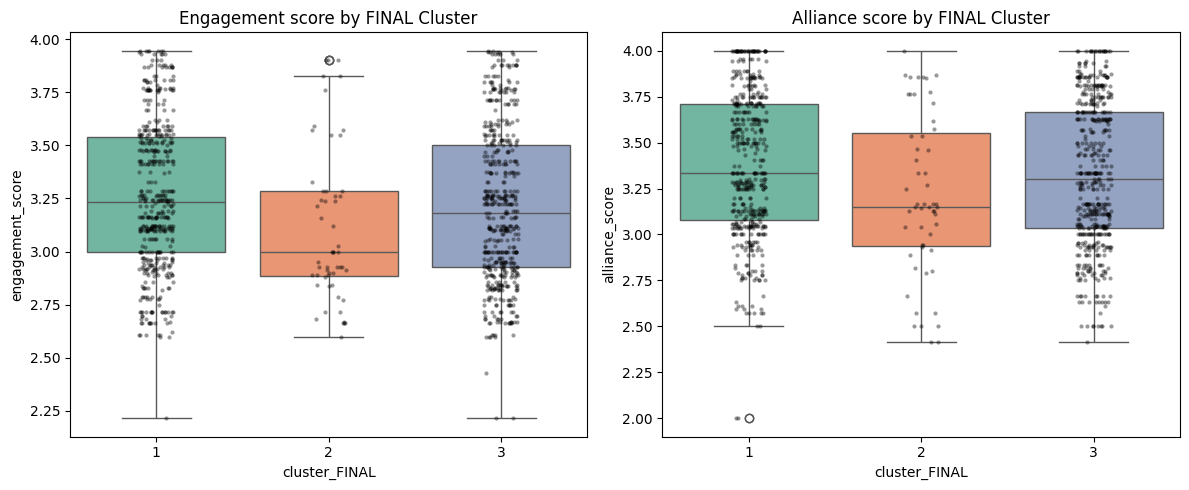

In [44]:
# ------------------------------------------------------------
# Engagement & Alliance cluster comparison
# ------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

# Separate columns
engagement_cols = [c for c in df.columns if re.match(r"SE\d+_avg$", c)]
alliance_cols   = [c for c in df.columns if re.match(r"SE\d+_TA_avg$", c)]

print("Engagement cols:", engagement_cols)
print("Alliance cols:", alliance_cols)

# Compute mean engagement and alliance per row
df["engagement_score"] = df[engagement_cols].mean(axis=1)
df["alliance_score"]   = df[alliance_cols].mean(axis=1)

# Summary stats by cluster
summary = (
    df.groupby("cluster_FINAL")[["engagement_score", "alliance_score"]]
      .agg(["mean", "std", "median", "min", "max", "count"])
)

print("Cluster-wise Engagement & Alliance Summary")
print(summary)

# Visualization
plt.figure(figsize=(12, 5))

for i, col in enumerate(["engagement_score", "alliance_score"], start=1):
    plt.subplot(1, 2, i)
    sns.boxplot(data=df, x="cluster_FINAL", y=col, palette="Set2")
    sns.stripplot(data=df, x="cluster_FINAL", y=col, color="black", size=3, alpha=0.4)
    plt.title(f"{col.replace('_',' ').capitalize()} by FINAL Cluster")

plt.tight_layout()
plt.show()


In [47]:
# ------------------------------------------------------------
# Engagement & Alliance analysis PER SESSION × FINAL cluster
# ------------------------------------------------------------

# Separate columns
engagement_cols = [c for c in df.columns if re.match(r"SE\d+_avg$", c)]
alliance_cols   = [c for c in df.columns if re.match(r"SE\d+_TA_avg$", c)]

# Compute scores per row (row = student × session)
df["engagement_score"] = df[engagement_cols].mean(axis=1)
df["alliance_score"]   = df[alliance_cols].mean(axis=1)

# Group by session × cluster
session_summary = (
    df.groupby(["session", "cluster_FINAL"])[["engagement_score", "alliance_score"]]
      .agg(["mean", "std", "median", "count"])
      .reset_index()
)

print("✅ Engagement & Alliance by Session × Cluster")
session_summary



✅ Engagement & Alliance by Session × Cluster


session cluster_FINAL engagement_score                            \
                                     mean       std    median count   
0        3             1         3.256172  0.392637  3.187075    42   
1        3             2         3.144274  0.395565  2.928571     5   
2        3             3         3.254297  0.371147  3.257937    50   
3        5             1         3.224786  0.367579  3.226190    60   
4        5             2         3.071429  0.350736  3.261905     3   
5        5             3         3.185023  0.355567  3.111111    57   
6        8             1         3.257779  0.346439  3.214286    65   
7        8             2         2.952381       NaN  2.952381     1   
8        8             3         3.152603  0.348749  3.119048    67   
9       10             1         3.341242  0.325505  3.414286    35   
10      10             2         2.965608  0.303288  2.928571     3   
11      10             3         3.167412  0.367328  3.116780    60   
12      11             1         3.182463  0.346978  3.122449    53   
13      11             2         3.168611  0.468422  3.071429    10   
14      11             3         3.207219  0.336374  3.183673    57   
15      15             1         3.312572  0.363898  3.264881    48   
16      15             2         3.110884  0.287486  3.000000     5   
17      15             3         3.235645  0.358147  3.242857    39   
18      18             1         3.262983  0.351244  3.240476    50   
19      18             2         3.071712  0.404763  3.000000     7   
20      18             3         3.178303  0.315530  3.107143    53   
21      20             1         3.287786  0.366500  3.228571    42   
22      20             2         3.111338  0.321642  2.928571     5   
23      20             3         3.218659  0.375650  3.206349    56   
24      24             1         3.260831  0.349748  3.238095    53   
25      24             2         2.899802  0.015433  2.899802     2   
26      24             3         3.359928  0.387854  3.371429    31   
27      25             1         3.266993  0.301581  3.225765    32   
28      25             2         3.157977  0.414348  3.119048    14   
29      25             3         3.237349  0.415954  3.236111    44   

   alliance_score                            
             mean       std    median count  
0        3.411297  0.395236  3.395833    42  
1        3.077434  0.597220  3.125000     5  
2        3.363669  0.408070  3.333333    50  
3        3.358904  0.382507  3.333333    60  
4        3.247795  0.478729  3.166667     3  
5        3.302875  0.395488  3.250000    57  
6        3.322873  0.407423  3.266667    65  
7        2.933333       NaN  2.933333     1  
8        3.332580  0.402574  3.333333    66  
9        3.464656  0.375600  3.518519    35  
10       2.972222  0.425599  2.791667     3  
11       3.292224  0.391446  3.292857    60  
12       3.254395  0.418732  3.266667    53  
13       3.150159  0.526671  3.027778    10  
14       3.333637  0.389133  3.277778    57  
15       3.474052  0.402372  3.509259    48  
16       3.388413  0.237846  3.333333     5  
17       3.346446  0.394866  3.300000    39  
18       3.414074  0.360854  3.425926    50  
19       3.274433  0.534967  3.166667     7  
20       3.264049  0.361681  3.200000    53  
21       3.405543  0.385666  3.379630    42  
22       3.405820  0.274366  3.333333     5  
23       3.331182  0.399839  3.333333    56  
24       3.384434  0.396868  3.458333    53  
25       3.136574  0.016368  3.136574     2  
26       3.468096  0.391714  3.619048    31  
27       3.444453  0.329099  3.466667    32  
28       3.222562  0.444274  3.145503    14  
29       3.318804  0.416139  3.208333    44

In [48]:
session_summary.session.value_counts()

session
3     3
5     3
8     3
10    3
11    3
15    3
18    3
20    3
24    3
25    3
Name: count, dtype: int64

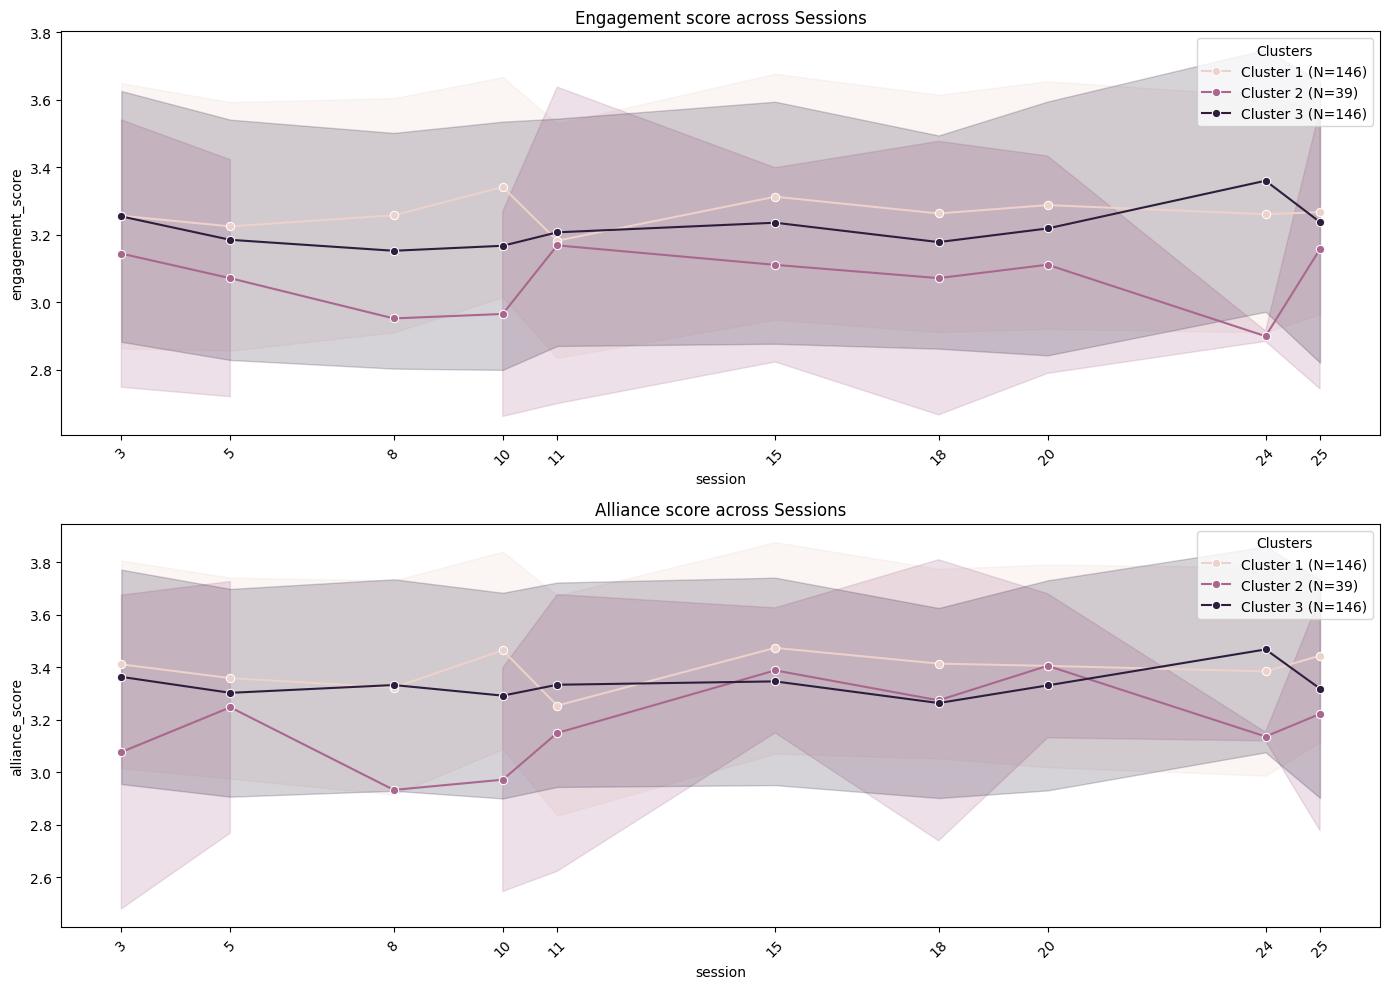

In [49]:
cluster_counts = df.groupby("cluster_FINAL")["StudentID"].nunique()
all_sessions = sorted(df["session"].unique())  # all session IDs

plt.figure(figsize=(14, 10))

for i, col in enumerate(["engagement_score", "alliance_score"], start=1):
    plt.subplot(2, 1, i)
    sns.lineplot(
        data=df,
        x="session",
        y=col,
        hue="cluster_FINAL",
        estimator="mean",
        errorbar="sd",
        marker="o"
    )
    # Add legend with N
    handles, labels = plt.gca().get_legend_handles_labels()
    new_labels = [
        f"Cluster {lab} (N={cluster_counts[int(lab)]})"
        if lab.isdigit() else lab
        for lab in labels
    ]
    plt.legend(handles, new_labels, title="Clusters")
    plt.title(f"{col.replace('_',' ').capitalize()} across Sessions")

    # ✅ Force every session to be displayed on x-axis
    plt.xticks(all_sessions, rotation=45)

plt.tight_layout()
plt.show()


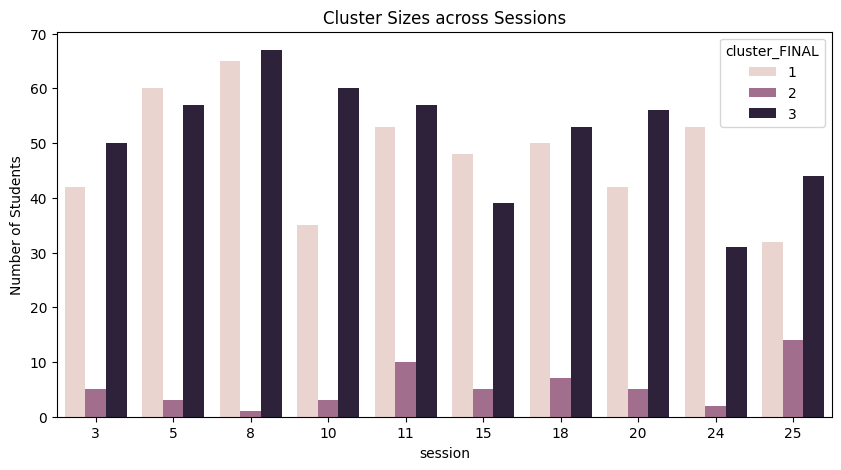

In [50]:
session_cluster_counts = (
    df.groupby(["session", "cluster_FINAL"])["StudentID"]
      .nunique()
      .reset_index(name="count")
)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=session_cluster_counts,
    x="session",
    y="count",
    hue="cluster_FINAL"
)
plt.title("Cluster Sizes across Sessions")
plt.ylabel("Number of Students")
plt.show()
